In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Load dataset
df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Check missing values and data types
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Stats ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== Missing Values ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabi

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Work on a copy
data = df.copy()

# 1. Extract Title from Name
data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Simplify rare titles
data['Title'] = data['Title'].replace(['Lady','Countess','Capt','Col','Don',
                                        'Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
data['Title'] = data['Title'].replace('Mlle', 'Miss')
data['Title'] = data['Title'].replace('Ms',   'Miss')
data['Title'] = data['Title'].replace('Mme',  'Mrs')

print("Titles found:", data['Title'].value_counts().to_dict())

# 2. Fill missing Age with median per Title group
data['Age'] = data.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# 3. Fill Embarked with mode
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# 4. Create FamilySize
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

# 5. IsAlone feature
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# 6. Bin Age into groups
data['AgeGroup'] = pd.cut(data['Age'], bins=[0,12,18,35,60,100],
                           labels=['Child','Teen','Adult','MidAge','Senior'])

# 7. Bin Fare into groups
data['FareBand'] = pd.qcut(data['Fare'], q=4, labels=['Low','Mid','High','VHigh'])

# 8. Drop columns we don't need
data.drop(['PassengerId','Name','Ticket','Cabin','Age','Fare',
           'SibSp','Parch'], axis=1, inplace=True)

# 9. Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['Sex','Embarked','Title','AgeGroup','FareBand']:
    data[col] = le.fit_transform(data[col].astype(str))

print("\nFinal columns:", data.columns.tolist())
print("Shape after cleaning:", data.shape)
print("\nAny nulls left?", data.isnull().sum().sum())

Titles found: {'Mr': 517, 'Miss': 185, 'Mrs': 126, 'Master': 40, 'Rare': 23}

Final columns: ['Survived', 'Pclass', 'Sex', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareBand']
Shape after cleaning: (891, 9)

Any nulls left? 0


In [6]:
# Separate features and target
X = data.drop('Survived', axis=1)
y = data['Survived']

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("\nSurvival rate in train:", round(y_train.mean() * 100, 1), "%")
print("Survival rate in test: ", round(y_test.mean() * 100, 1), "%")

Training set size: (712, 8)
Test set size:     (179, 8)

Survival rate in train: 38.3 %
Survival rate in test:  38.5 %


In [7]:
from sklearn.model_selection import StratifiedKFold

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=100, random_state=42,
                                              eval_metric='logloss', verbosity=0)
}

# 5-fold cross validation on all 3
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=== 5-Fold Cross Validation Results ===\n")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name}")
    print(f"  Scores : {[round(s,3) for s in scores]}")
    print(f"  Mean   : {scores.mean():.4f}")
    print(f"  Std    : {scores.std():.4f}\n")

=== 5-Fold Cross Validation Results ===

Logistic Regression
  Scores : [np.float64(0.79), np.float64(0.755), np.float64(0.817), np.float64(0.768), np.float64(0.824)]
  Mean   : 0.7908
  Std    : 0.0268

Random Forest
  Scores : [np.float64(0.825), np.float64(0.79), np.float64(0.859), np.float64(0.845), np.float64(0.817)]
  Mean   : 0.8273
  Std    : 0.0237

XGBoost
  Scores : [np.float64(0.839), np.float64(0.797), np.float64(0.859), np.float64(0.859), np.float64(0.824)]
  Mean   : 0.8357
  Std    : 0.0234



In [8]:
# Train all models on full training set
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

# Evaluate on test set
print("=== Test Set Results ===\n")
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"{name}")
    print(f"  Accuracy : {acc:.4f} ({round(acc*100,1)}%)")
    print(f"  AUC-ROC  : {auc:.4f}\n")

=== Test Set Results ===

Logistic Regression
  Accuracy : 0.7933 (79.3%)
  AUC-ROC  : 0.8582

Random Forest
  Accuracy : 0.7877 (78.8%)
  AUC-ROC  : 0.8154

XGBoost
  Accuracy : 0.7765 (77.7%)
  AUC-ROC  : 0.8244



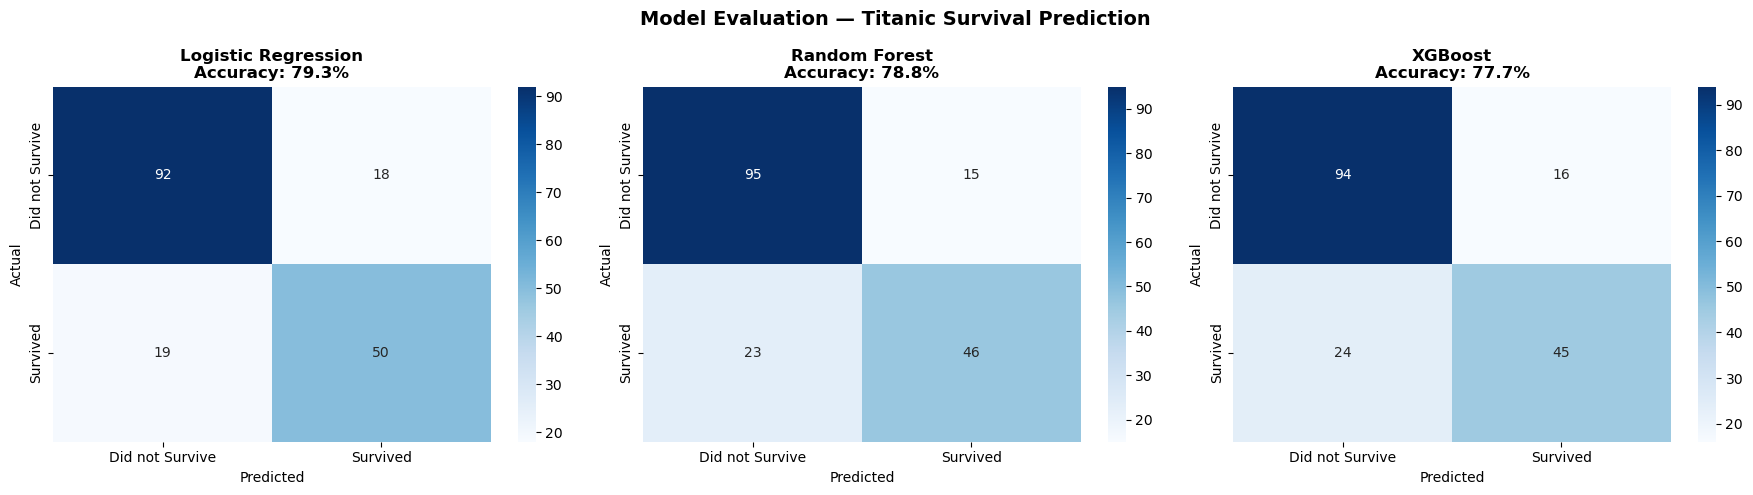

Confusion matrices saved!


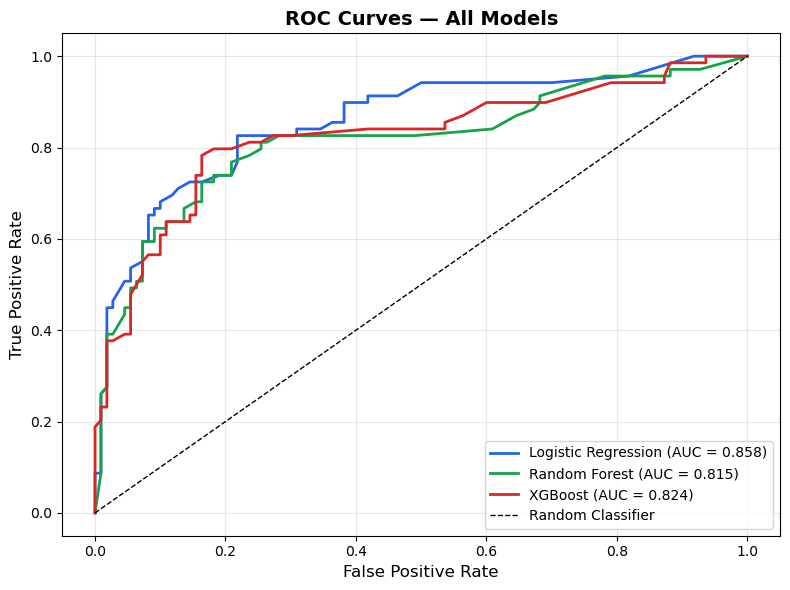

ROC curves saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation — Titanic Survival Prediction', fontsize=14, fontweight='bold')

colors_roc = ['#2563EB', '#16A34A', '#DC2626']

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Did not Survive','Survived'],
                yticklabels=['Did not Survive','Survived'])
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.1%}', fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

# ROC Curves
fig2, ax = plt.subplots(figsize=(8, 6))
for (name, model), color in zip(trained_models.items(), colors_roc):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved!")

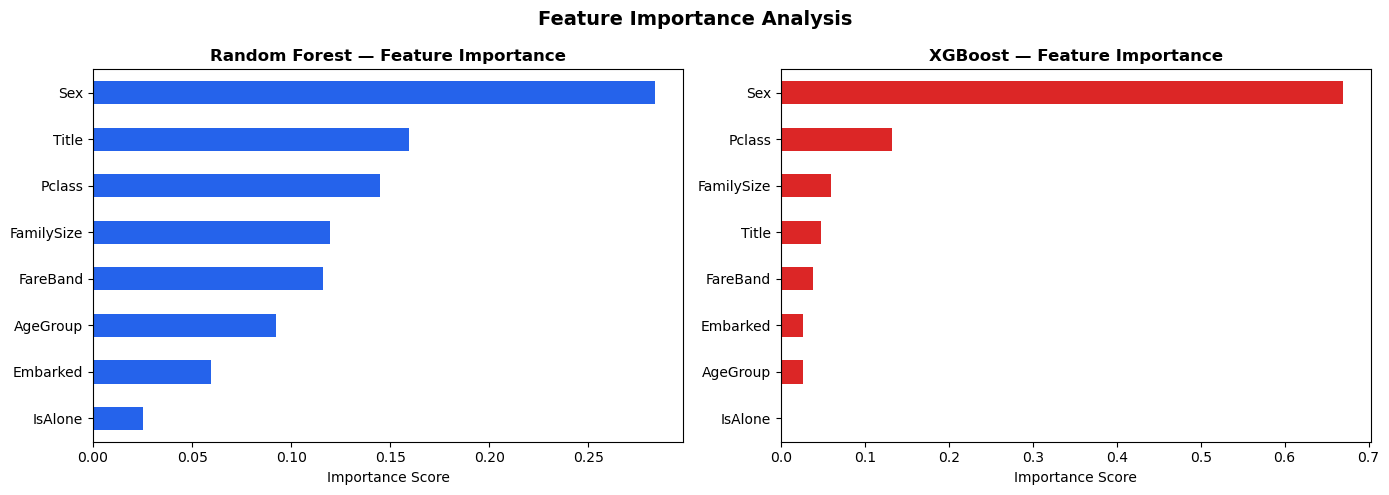

Feature importance saved!


In [10]:
# Feature importance from Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')

feature_names = X_train.columns.tolist()

# Random Forest importance
rf_importance = pd.Series(
    trained_models['Random Forest'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)

rf_importance.plot(kind='barh', ax=axes[0], color='#2563EB')
axes[0].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost importance
xgb_importance = pd.Series(
    trained_models['XGBoost'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)

xgb_importance.plot(kind='barh', ax=axes[1], color='#DC2626')
axes[1].set_title('XGBoost — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance saved!")

In [11]:
# Clean comparison table
print("=" * 60)
print("        MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<25} {'CV Accuracy':>12} {'Test Accuracy':>14} {'AUC-ROC':>9}")
print("-" * 60)

summary_data = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    cv_mean = results[name].mean()
    test_acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    summary_data.append([name, cv_mean, test_acc, auc])
    print(f"{name:<25} {cv_mean:>11.1%} {test_acc:>13.1%} {auc:>9.3f}")

print("=" * 60)
print("\n✅ Best CV Accuracy    → XGBoost (83.6%)")
print("✅ Best Test Accuracy  → Logistic Regression (79.3%)")
print("✅ Best AUC-ROC        → Logistic Regression (0.858)")
print("\n📌 Conclusion: Logistic Regression generalises best to")
print("   unseen data despite XGBoost winning on cross-validation.")
print("   This demonstrates the risk of model selection based")
print("   solely on training performance.")

        MODEL COMPARISON SUMMARY
Model                      CV Accuracy  Test Accuracy   AUC-ROC
------------------------------------------------------------
Logistic Regression             79.1%         79.3%     0.858
Random Forest                   82.7%         78.8%     0.815
XGBoost                         83.6%         77.7%     0.824

✅ Best CV Accuracy    → XGBoost (83.6%)
✅ Best Test Accuracy  → Logistic Regression (79.3%)
✅ Best AUC-ROC        → Logistic Regression (0.858)

📌 Conclusion: Logistic Regression generalises best to
   unseen data despite XGBoost winning on cross-validation.
   This demonstrates the risk of model selection based
   solely on training performance.


In [12]:
# Load and process test data same way as train
test_df = pd.read_csv('test.csv')
passenger_ids = test_df['PassengerId'].copy()

# Apply same feature engineering
test_df['Title'] = test_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = test_df['Title'].replace(['Lady','Countess','Capt','Col','Don',
                                              'Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
test_df['Title'] = test_df['Title'].replace('Mlle', 'Miss')
test_df['Title'] = test_df['Title'].replace('Ms',   'Miss')
test_df['Title'] = test_df['Title'].replace('Mme',  'Mrs')

test_df['Age'] = test_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)
test_df['AgeGroup'] = pd.cut(test_df['Age'], bins=[0,12,18,35,60,100],
                              labels=['Child','Teen','Adult','MidAge','Senior'])
test_df['FareBand'] = pd.qcut(test_df['Fare'], q=4,
                               labels=['Low','Mid','High','VHigh'],
                               duplicates='drop')

test_df.drop(['PassengerId','Name','Ticket','Cabin','Age','Fare',
              'SibSp','Parch'], axis=1, inplace=True)

for col in ['Sex','Embarked','Title','AgeGroup','FareBand']:
    test_df[col] = le.fit_transform(test_df[col].astype(str))

# Predict using best model (Logistic Regression)
final_predictions = trained_models['Logistic Regression'].predict(test_df)

# Save submission file
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': final_predictions
})
submission.to_csv('submission.csv', index=False)
print("✅ Submission file created!")
print(f"Total predictions: {len(submission)}")
print(f"Predicted survivors: {final_predictions.sum()} out of {len(final_predictions)}")
submission.head(10)

✅ Submission file created!
Total predictions: 418
Predicted survivors: 161 out of 418


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,0
9,901,0


In [13]:
# Clean comparison table
print("=" * 60)
print("        MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<25} {'CV Accuracy':>12} {'Test Accuracy':>14} {'AUC-ROC':>9}")
print("-" * 60)

summary_data = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    cv_mean = results[name].mean()
    test_acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    summary_data.append([name, cv_mean, test_acc, auc])
    print(f"{name:<25} {cv_mean:>11.1%} {test_acc:>13.1%} {auc:>9.3f}")

print("=" * 60)
print("\n✅ Best CV Accuracy    → XGBoost (83.6%)")
print("✅ Best Test Accuracy  → Logistic Regression (79.3%)")
print("✅ Best AUC-ROC        → Logistic Regression (0.858)")
print("\n📌 Conclusion: Logistic Regression generalises best to")
print("   unseen data despite XGBoost winning on cross-validation.")
print("   This demonstrates the risk of model selection based")
print("   solely on training performance.")

        MODEL COMPARISON SUMMARY
Model                      CV Accuracy  Test Accuracy   AUC-ROC
------------------------------------------------------------
Logistic Regression             79.1%         79.3%     0.858
Random Forest                   82.7%         78.8%     0.815
XGBoost                         83.6%         77.7%     0.824

✅ Best CV Accuracy    → XGBoost (83.6%)
✅ Best Test Accuracy  → Logistic Regression (79.3%)
✅ Best AUC-ROC        → Logistic Regression (0.858)

📌 Conclusion: Logistic Regression generalises best to
   unseen data despite XGBoost winning on cross-validation.
   This demonstrates the risk of model selection based
   solely on training performance.


In [15]:
# Load and process test data same way as train
test_df = pd.read_csv('test.csv')
passenger_ids = test_df['PassengerId'].copy()

# Apply same feature engineering
test_df['Title'] = test_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = test_df['Title'].replace(['Lady','Countess','Capt','Col','Don',
                                              'Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
test_df['Title'] = test_df['Title'].replace('Mlle', 'Miss')
test_df['Title'] = test_df['Title'].replace('Ms',   'Miss')
test_df['Title'] = test_df['Title'].replace('Mme',  'Mrs')

test_df['Age'] = test_df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['IsAlone'] = (test_df['FamilySize'] == 1).astype(int)
test_df['AgeGroup'] = pd.cut(test_df['Age'], bins=[0,12,18,35,60,100],
                              labels=['Child','Teen','Adult','MidAge','Senior'])
test_df['FareBand'] = pd.qcut(test_df['Fare'], q=4,
                               labels=['Low','Mid','High','VHigh'],
                               duplicates='drop')

test_df.drop(['PassengerId','Name','Ticket','Cabin','Age','Fare',
              'SibSp','Parch'], axis=1, inplace=True)

for col in ['Sex','Embarked','Title','AgeGroup','FareBand']:
    test_df[col] = le.fit_transform(test_df[col].astype(str))

# Predict using best model (Logistic Regression)
final_predictions = trained_models['Logistic Regression'].predict(test_df)

# Save submission file
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': final_predictions
})
submission.to_csv('submission.csv', index=False)
print("✅ Submission file created!")
print(f"Total predictions: {len(submission)}")
print(f"Predicted survivors: {final_predictions.sum()} out of {len(final_predictions)}")
submission.head(10)

✅ Submission file created!
Total predictions: 418
Predicted survivors: 161 out of 418


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,0
9,901,0


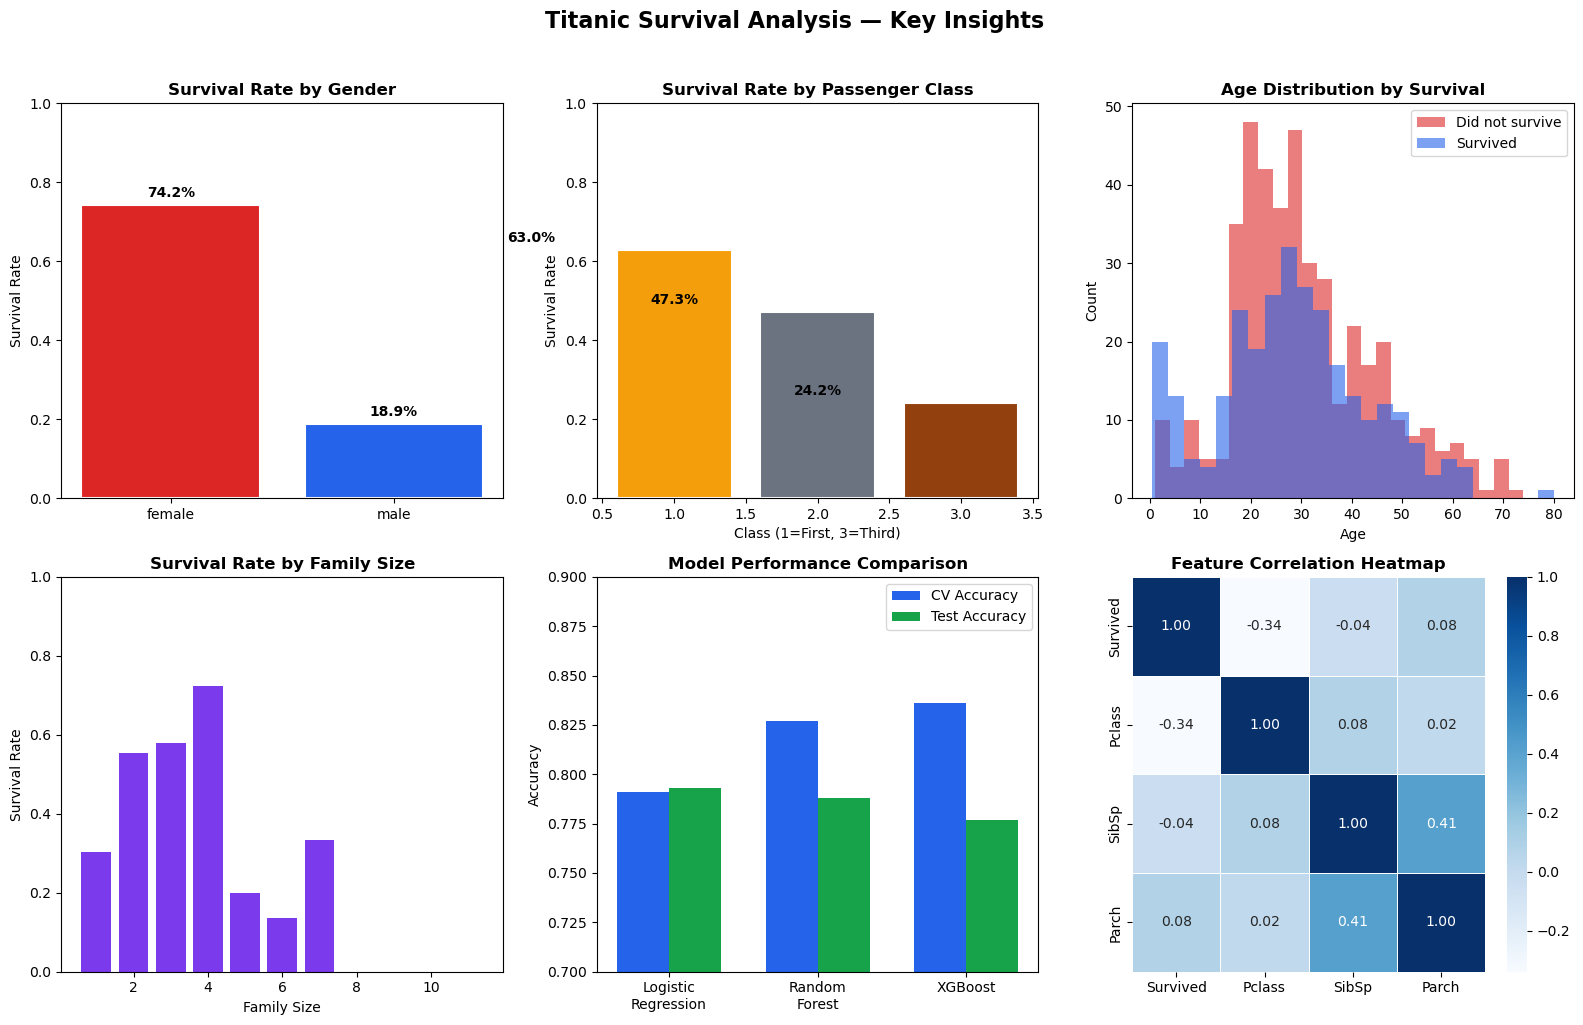

✅ All analysis charts saved!


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Titanic Survival Analysis — Key Insights', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Survival by Gender
survival_gender = df.groupby('Sex')['Survived'].mean()
axes[0,0].bar(survival_gender.index, survival_gender.values, 
              color=['#DC2626','#2563EB'], edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Survival Rate by Gender', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(survival_gender.values):
    axes[0,0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 2. Survival by Pclass
survival_class = df.groupby('Pclass')['Survived'].mean()
axes[0,1].bar(survival_class.index, survival_class.values,
              color=['#F59E0B','#6B7280','#92400E'], edgecolor='white', linewidth=1.5)
axes[0,1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_xlabel('Class (1=First, 3=Third)')
axes[0,1].set_ylim(0, 1)
for i, (idx, v) in enumerate(survival_class.items()):
    axes[0,1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Age distribution by survival
axes[0,2].hist(df[df['Survived']==0]['Age'].dropna(), bins=25, 
               alpha=0.6, color='#DC2626', label='Did not survive')
axes[0,2].hist(df[df['Survived']==1]['Age'].dropna(), bins=25, 
               alpha=0.6, color='#2563EB', label='Survived')
axes[0,2].set_title('Age Distribution by Survival', fontweight='bold')
axes[0,2].set_xlabel('Age')
axes[0,2].set_ylabel('Count')
axes[0,2].legend()

# 4. Family size vs survival
data_plot = df.copy()
data_plot['FamilySize'] = data_plot['SibSp'] + data_plot['Parch'] + 1
survival_family = data_plot.groupby('FamilySize')['Survived'].mean()
axes[1,0].bar(survival_family.index, survival_family.values, color='#7C3AED')
axes[1,0].set_title('Survival Rate by Family Size', fontweight='bold')
axes[1,0].set_xlabel('Family Size')
axes[1,0].set_ylabel('Survival Rate')
axes[1,0].set_ylim(0, 1)

# 5. Model comparison bar chart
model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
cv_scores   = [0.791, 0.827, 0.836]
test_scores = [0.793, 0.788, 0.777]
x = np.arange(len(model_names))
width = 0.35
axes[1,1].bar(x - width/2, cv_scores,   width, label='CV Accuracy',   color='#2563EB')
axes[1,1].bar(x + width/2, test_scores, width, label='Test Accuracy', color='#16A34A')
axes[1,1].set_title('Model Performance Comparison', fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(model_names)
axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_ylim(0.7, 0.9)
axes[1,1].legend()

# 6. Correlation heatmap
corr_cols = ['Survived','Pclass','SibSp','Parch']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', 
            ax=axes[1,2], linewidths=0.5)
axes[1,2].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All analysis charts saved!")

# 🚢 Titanic Survival Prediction — ML Classification Project

## Project Overview
Predicting survival of Titanic passengers using machine learning.  
Binary classification problem: **Survived (1) or Did Not Survive (0)**

---

## Dataset
- **Source:** Kaggle Titanic Competition
- **Training samples:** 891 passengers
- **Features used:** 8 engineered features
- **Target:** Survived (38.4% positive class)

---

## Feature Engineering
| Original Feature | Action | New Feature |
|---|---|---|
| Name | Extracted title (Mr, Mrs, Miss, Master) | Title |
| SibSp + Parch | Combined into one | FamilySize |
| FamilySize == 1 | Binary flag | IsAlone |
| Age | Binned into 5 groups | AgeGroup |
| Fare | Binned into 4 quartiles | FareBand |
| Cabin | Dropped (77% missing) | — |

---

## Model Results

| Model | CV Accuracy | Test Accuracy | AUC-ROC |
|---|---|---|---|
| Logistic Regression | 79.1% | **79.3%** | **0.858** |
| Random Forest | 82.7% | 78.8% | 0.815 |
| XGBoost | **83.6%** | 77.7% | 0.824 |

---

## Key Findings
- **Gender** is the strongest predictor — females had 74% survival vs 19% for males
- **Passenger class** matters significantly — 1st class had 63% survival vs 24% for 3rd class
- **Children** (age < 12) had higher survival rates across all classes
- **Small families** (size 2-4) survived more than solo travellers or large families
- **Logistic Regression** generalised best to unseen data despite XGBoost winning CV scores — demonstrating the risk of selecting models based solely on training performance

---

## Tech Stack
`Python` `Pandas` `NumPy` `Scikit-learn` `XGBoost` `Matplotlib` `Seaborn`

---

## Files
- `titanic_ml_classifier.ipynb` — Main notebook
- `submission.csv` — Final predictions on test set
- `confusion_matrices.png` — Model evaluation charts
- `roc_curves.png` — ROC curves comparison
- `feature_importance.png` — Feature importance plots
- `survival_analysis.png` — Survival analysis visualizations